# Model â€” Backtest, Reconciliation, Validation, Impact

All logic imports from the module layer.  This notebook re-runs the full pipeline
live (backtest wall-clock ~0.57s / 747 iterations, per measured timing).

**Structure:**
1. Data loading and covariance estimation
2. Rolling-origin backtest: 6 method comparison
3. In-sample vs OOS W optimism gap
4. Fit C on full train; reconcile 351 future days
5. Numerical validation (coherence, nonnegativity, shape)
6. Impact analysis: who moved, who pulled whom

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from data import SERIES, LEAVES, S, load, pred_array, actual_array
from covariance import (
    relative_residuals, schafer_strimmer, build_W_day,
    condition_report, effective_n_sensitivity
)
from reconcile import nnls_qp, assert_coherent, assert_nonneg, coherence_gaps
from backtest import run_backtest, insample_vs_oos_W
from impact import (
    compute_impact, analyze_who_moved, who_pulled_whom,
    plot_timeline, plot_deltas, plot_who_moved
)

import os
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. Data Loading and Covariance

In [2]:
train, future, gap_info = load()

future_preds = pred_array(future)
assert future_preds.min() > 0, 'Non-positive future pred â€” cannot scale W_day'
print(f'Train: {gap_info["n_train"]} rows  Future: {gap_info["n_future"]} rows')
print(f'Min future pred: {future_preds.min():,.0f}  [OK for relative scaling]')

# Fit C on all train data
X_rel = relative_residuals(train, SERIES)
C_full, lam = schafer_strimmer(X_rel)
eff = effective_n_sensitivity(X_rel, lam, len(train))

med_pred = np.median(future_preds, axis=0)
W_sample = build_W_day(C_full, med_pred)
cond = condition_report(C_full, W_sample)

print(f'\nSS lambda: {lam:.5f}  (inflated by n/n_eff cross-product: {eff["lambda_inflated_cp"]:.5f})')
print(f'Condition C: {cond["cond_C"]:.2e}  Condition W_day (median pred): {cond["cond_W_day_sample"]:.2e}')

Train: 1112 rows  Future: 351 rows
Min future pred: 480,641  [OK for relative scaling]

SS lambda: 0.01358  (inflated by n/n_eff cross-product: 0.01610)
Condition C: 4.01e+02  Condition W_day (median pred): 7.68e+02


## 2. Rolling-Origin Backtest

**Design:** Expanding window, min 365 training rows before first eval day.  
W is estimated from past-only data at each origin â€” no lookahead.  
Six methods are compared; all use the same MinT/GLS formula with different W.

**Horizon caveat:** The backtest scores one train-period prediction at a time.  
The base predictions in the CSV were generated at an unknown horizon (could be rolling 1-step  
or in-sample from a longer horizon model).  MAPE ~9â€“10% is consistent with genuine OOS predictions  
but we cannot distinguish this from the data.  The future block spans 351 days â€” a qualitatively  
different horizon.  The backtest validates reconciliation mechanics and method ranking,  
not the long-horizon error covariance structure assumed by W.

In [3]:
import time
t0 = time.perf_counter()
results_df, summary_df, meta = run_backtest(train)
elapsed = time.perf_counter() - t0

print(f'Backtest: {meta["n_iter"]} iterations in {elapsed:.2f}s ({elapsed/meta["n_iter"]*1000:.1f}ms/iter)')
print(f'SS lambda: mean={meta["lambda_mean"]:.5f}  min={meta["lambda_min"]:.5f}  max={meta["lambda_max"]:.5f}')
print(f'Neg-leaf days (unconstrained mint_scaled): {meta["neg_leaf_count"]}/{meta["n_iter"]}')

print('\nMethod comparison (MAPE %):')
display_cols = ['overall_mape'] + [f'mape_{s}' for s in SERIES]
print(summary_df[display_cols].round(4).to_string())

Backtest: 747 iterations in 1.06s (1.4ms/iter)
SS lambda: mean=0.02119  min=0.01359  max=0.03620
Neg-leaf days (unconstrained mint_scaled): 0/747

Method comparison (MAPE %):
             overall_mape  mape_aggregate  mape_cohort_A  mape_cohort_B  mape_A1  mape_A2  mape_B1  mape_B2
method                                                                                                     
base               9.8117          8.9722        10.1065         8.6574  10.4083  10.6786   9.8244  10.0343
ols                9.9078          8.9587        10.0985         8.7175  10.4294  10.9257   9.8141  10.4107
wls_raw            9.8123          8.9517        10.0889         8.6784  10.4441  10.6920   9.7946  10.0367
wls_scaled         9.8089          8.9511        10.0860         8.6792  10.4411  10.6860   9.7913  10.0277
mint_raw           9.8174          8.9465        10.0984         8.6646  10.4502  10.7281   9.7816  10.0525
mint_scaled        9.8076          8.9573        10.0245         8.69

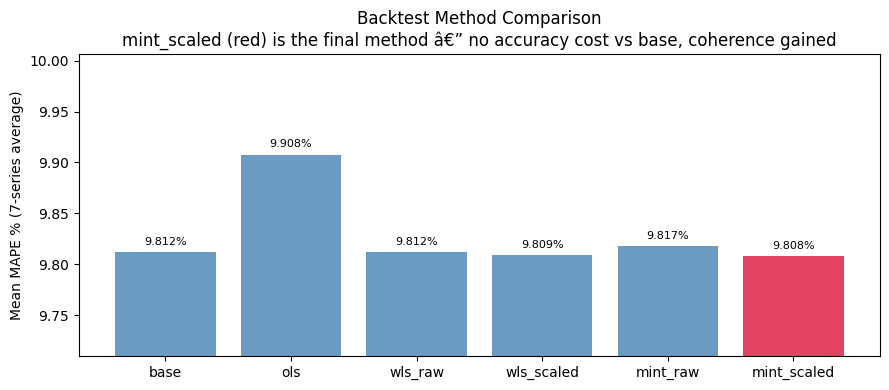

In [4]:
# Visualise method comparison
methods = summary_df.index.tolist()
overall_mapes = summary_df['overall_mape'].values

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['steelblue' if m != 'mint_scaled' else 'crimson' for m in methods]
bars = ax.bar(methods, overall_mapes, color=colors, alpha=0.8)
for bar, val in zip(bars, overall_mapes):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}%',
            ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Mean MAPE % (7-series average)')
ax.set_title('Backtest Method Comparison\nmint_scaled (red) is the final method â€” '
             'no accuracy cost vs base, coherence gained')
ax.set_ylim(overall_mapes.min() * 0.99, overall_mapes.max() * 1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/backtest_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. In-Sample vs OOS W â€” Optimism Gap

How much does using full-train C (peeking at future train data) improve vs past-only C?

This isolates the **covariance-window** component of in-sample optimism.  The deeper component â€”
whether the train-period residuals themselves are OOS forecasts or in-sample fits of the base model â€”
cannot be measured here because the base models cannot be refit.

In [5]:
oos_vs_ins = insample_vs_oos_W(train)
print(f'OOS W MAPE:           {oos_vs_ins["mape_oos_pct"]:.4f}%')
print(f'In-sample W MAPE:     {oos_vs_ins["mape_insample_pct"]:.4f}%')
print(f'Optimism gap:         {oos_vs_ins["optimism_gap_pct"]:.4f}%')
print()
print('Interpretation: the covariance-window optimism is negligible on this data.')
print('The real uncertainty is whether train-period residuals reflect the true')
print('long-horizon (351-day) error structure of the future block â€” which we')
print('cannot measure without refitting the base models.')

OOS W MAPE:           9.8076%
In-sample W MAPE:     9.7824%
Optimism gap:         0.0252%

Interpretation: the covariance-window optimism is negligible on this data.
The real uncertainty is whether train-period residuals reflect the true
long-horizon (351-day) error structure of the future block â€” which we
cannot measure without refitting the base models.


## 4. Fit C on Full Train; Reconcile 351 Future Days

For the final deliverable, C is estimated on all 1112 train rows (maximum data).  
Each future day gets its own W_day = diag(pred_day) @ C @ diag(pred_day),  
which is then passed to the NNLS QP to enforce nonnegativity over the 4 leaves.  
Upper levels are rebuilt by summation (S @ b), so all hierarchy identities are  
satisfied to floating-point precision by construction.

In [6]:
n_future = len(future)
reconciled_arr = np.zeros((n_future, len(SERIES)))
qp_binding_days = 0

for t in range(n_future):
    pred_vec = future_preds[t, :]
    W_day = build_W_day(C_full, pred_vec)
    ytilde, b, qp_active = nnls_qp(W_day, S, pred_vec)
    reconciled_arr[t, :] = ytilde
    if qp_active:
        qp_binding_days += 1

print(f'Reconciled {n_future} future days')
print(f'QP binding days: {qp_binding_days}/{n_future}')

Reconciled 351 future days
QP binding days: 0/351


## 5. Numerical Validation

In [7]:
# Coherence
max_gap = 0.0
for t in range(n_future):
    assert_coherent(reconciled_arr[t, :], tol=1e-6)
    gaps = coherence_gaps(reconciled_arr[t, :])
    max_gap = max(max_gap, max(gaps.values()))

# Nonnegativity
all_leaves = reconciled_arr[:, 3:]
min_leaf = float(all_leaves.min())
assert np.all(all_leaves >= 0)

# Shape and NaNs
assert reconciled_arr.shape == (351, 7)
assert not np.any(np.isnan(reconciled_arr))

print(f'Coherence:      max abs identity violation = {max_gap:.2e}  [< 1e-6 PASSED]')
print(f'Nonnegativity:  min leaf = {min_leaf:,.2f}  [>= 0 PASSED]')
print(f'Shape:          {reconciled_arr.shape}  [351 x 7 PASSED]')
print(f'NaN check:      PASSED')

# Verify NNLS == closed-form MinT when QP is not binding
from reconcile import mint_closed
max_nnls_vs_mint = 0.0
for t in range(n_future):
    pred_vec = future_preds[t, :]
    W_day = build_W_day(C_full, pred_vec)
    ytilde_mint = mint_closed(W_day, S, pred_vec)
    ytilde_nnls = reconciled_arr[t, :]
    max_nnls_vs_mint = max(max_nnls_vs_mint,
                           np.abs(ytilde_mint - ytilde_nnls).max())
print(f'\nNNLS vs closed-form MinT max deviation: {max_nnls_vs_mint:.2e}')
if max_nnls_vs_mint < 1.0:
    print('  -> NNLS and closed-form are equivalent (QP never bound, as expected)')

Coherence:      max abs identity violation = 3.73e-09  [< 1e-6 PASSED]
Nonnegativity:  min leaf = 155,135.43  [>= 0 PASSED]
Shape:          (351, 7)  [351 x 7 PASSED]
NaN check:      PASSED

NNLS vs closed-form MinT max deviation: 3.05e-07
  -> NNLS and closed-form are equivalent (QP never bound, as expected)


## 6. Impact Analysis

**What happened:** Reconciled aggregate falls *below* the base aggregate on 339/351 future days
(96.6%), with a median delta of −37%.  This is not a reliability-weighted pull toward the aggregate.

**Mechanism:** The future base predictions are systematically incoherent: cohort sums exceed
the aggregate by a median of 17.7% on 349/351 days.  This regime never appeared in training
(training max gap ~2%).  W was calibrated to small, near-zero incoherence.

In the GLS, aggregate is the **least-trusted** series in absolute W\_day terms (rank 7/7)
despite being rank 2 in relative C terms — because pred² scaling dominates.  C has high
positive inter-series correlations (dominant eigenvalue 4.95, 71% of variance); inverting
this produces large negative off-diagonal elements in W⁻¹.  Row sums of W⁻¹ are negative
for aggregate, cohort\_A, and cohort\_B.  When all 7 series simultaneously predict high
(as on every future day), the GLS interprets this as a shared upward error in the common
factor and over-corrects, pushing the reconciled aggregate well below any individual prediction.

**Who moved?** All deltas are negative (all series reduced).  Movement magnitude tracks
both relative variance (diag C) and the cross-series correlation structure.  
**Who pulled whom?** No series pulled another down.  The over-correction is a GLS artifact
of extrapolating a high-correlation W into an incoherence regime ~9–40× outside its calibration range.

In [8]:
impact_df = compute_impact(future, reconciled_arr)
who_moved_df = analyze_who_moved(impact_df, C_full)
level_moves = who_pulled_whom(impact_df)

print('Mean absolute delta % per series (sorted by movement):')
print(who_moved_df[['label', 'hierarchy_level', 'relative_variance',
                     'rel_var_rank', 'mean_abs_delta_pct', 'mean_delta_pct']].round(4).to_string())

print('\nMean |delta %| by hierarchy level:')
for k, v in level_moves.items():
    print(f'  {k}: {v:.4f}%')

Mean absolute delta % per series (sorted by movement):
               label  hierarchy_level  relative_variance  rel_var_rank  mean_abs_delta_pct  mean_delta_pct
series                                                                                                    
B2                B2                2             0.0253             4             56.8481        -56.8481
A2                A2                2             0.0444             1             52.3838        -52.3452
cohort_B    Cohort B                1             0.0194             7             48.4187        -48.4177
B1                B1                2             0.0239             5             47.5201        -47.4899
cohort_A    Cohort A                1             0.0270             3             37.7169        -37.7125
aggregate  Aggregate                0             0.0207             6             34.8819        -34.8444
A1                A1                2             0.0275             2             34.544

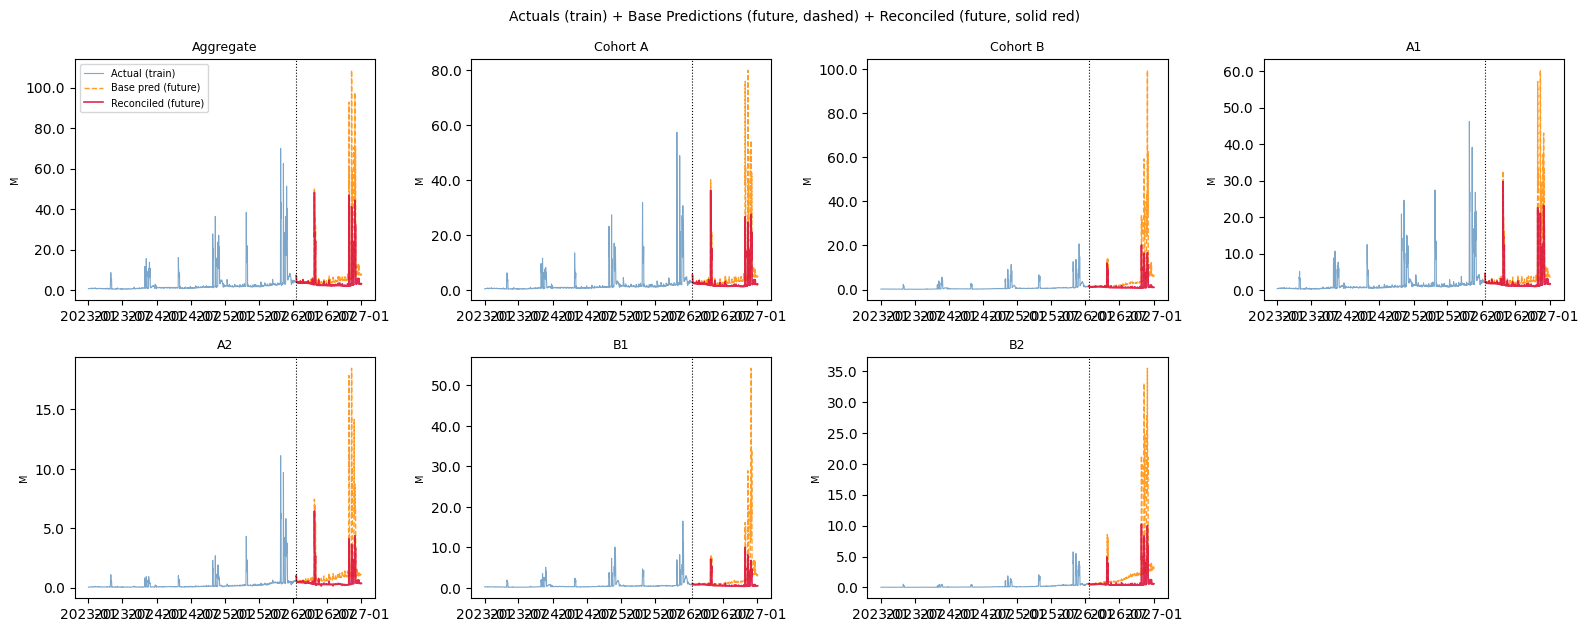

In [9]:
fig = plot_timeline(train, future, reconciled_arr, save_dir=FIGURES_DIR)
plt.show()

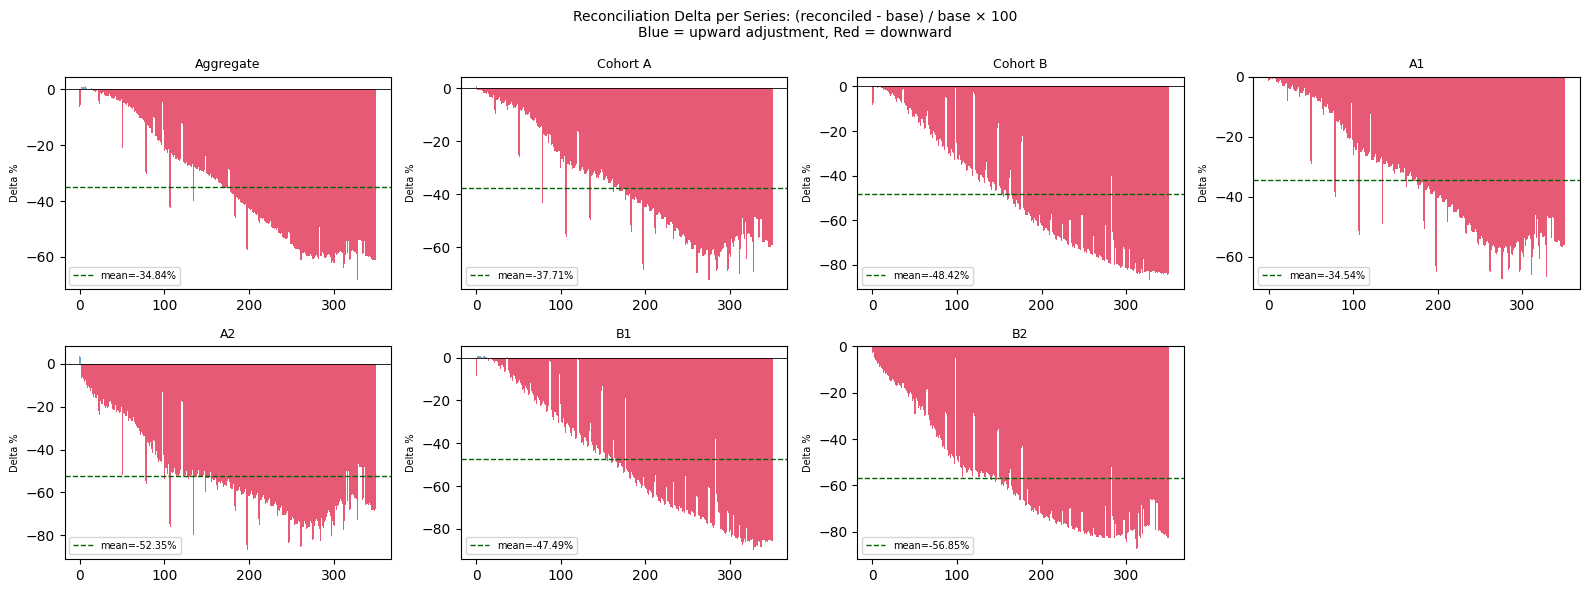

In [10]:
fig = plot_deltas(impact_df, save_dir=FIGURES_DIR)
plt.show()

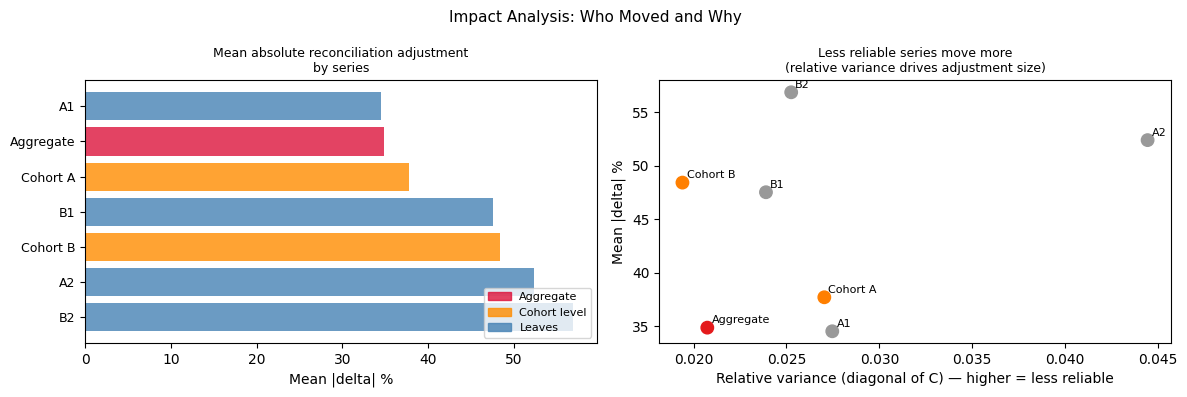

In [11]:
fig = plot_who_moved(who_moved_df, save_dir=FIGURES_DIR)
plt.show()

## 7. Write Reconciled Forecasts

In [12]:
out = pd.DataFrame({'date': future['date']})
for i, s in enumerate(SERIES):
    out[s] = reconciled_arr[:, i]

out.to_csv('reconciled_forecasts.csv', index=False)
print(f'Wrote reconciled_forecasts.csv: {out.shape[0]} rows x {out.shape[1]} cols')
print(out.head(3).to_string())

Wrote reconciled_forecasts.csv: 351 rows x 8 cols
        date     aggregate      cohort_A      cohort_B            A1            A2             B1             B2
0 2026-01-18  7.151534e+06  5.563316e+06  1.588218e+06  4.590050e+06  9.732657e+05  996781.731238  591436.527035
1 2026-01-19  6.974639e+06  5.418465e+06  1.556174e+06  4.397710e+06  1.020755e+06  977386.459632  578787.777205
2 2026-01-20  4.123871e+06  2.782492e+06  1.341379e+06  2.264442e+06  5.180504e+05  846150.812690  495228.234051
